<a href="https://colab.research.google.com/github/onepartho/.github/blob/main/water_river.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
Unexpected token 'X', "X,Y,Z,WQI,"... is not valid JSON
SyntaxError: Unexpected token 'X', "X,Y,Z,WQI,"... is not valid JSON
    at JSON.parse (<anonymous>)
    at https://ssl.gstatic.com/colaboratory-static/common/b68f8747a278556fe77e4eaf1b4e3357/external_binary_es6.js:4655:466
    at next (<anonymous>)
    at b (https://ssl.gstatic.com/colaboratory-static/common/b68f8747a278556fe77e4eaf1b4e3357/external_binary_es6.js:6:40)

SyntaxError: invalid syntax (1140572369.py, line 1)

In [2]:
  File "/tmp/ipykernel_519/1140572369.py", line 1
    Unexpected token 'X', "X,Y,Z,WQI,"... is not valid JSON
               ^
SyntaxError: invalid syntax


SyntaxError: invalid syntax (3019594606.py, line 1)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-povray.
(Reading database ... 122797 files and directories currently installed.)
Preparing to unpack .../0-fonts-povray_1%3a3.7.0.10-3build4_all.deb ...
Unpacking fonts-povray (1:3.7.0.10-3build4) ...
Selecting previously unselected package libboost-thread1.83.0:amd64.
Preparing to unpack .../1-libboost-thread1.83.0_1.83.0-2.1ubuntu3.2_amd64.deb ...
Unpacking libboost-thread1.83.0:amd64 (1.83.0-2.1ubuntu3.2) ...
Selecting previously unselected package libimath-3-1-29t64:amd64.
Preparing to unpack .../2-libimath-3-1-29t64_3.1.9-3.1ubuntu2_amd64.deb ...
Unpacking libimath-3-1-29t64:amd64 (3.1.9-3.1ubuntu2) ...
Selecting previously unselected package libopenexr-3-1-30:amd64.
Preparing to unpack .../3-libopenexr-3-1-30_3.1.5-5.1build3_amd64.deb ...
Unpacking 

Saving Reproducible_Dataset.xlsx to Reproducible_Dataset.xlsx
Loaded 660 samples across 10 physicochemical parameters.


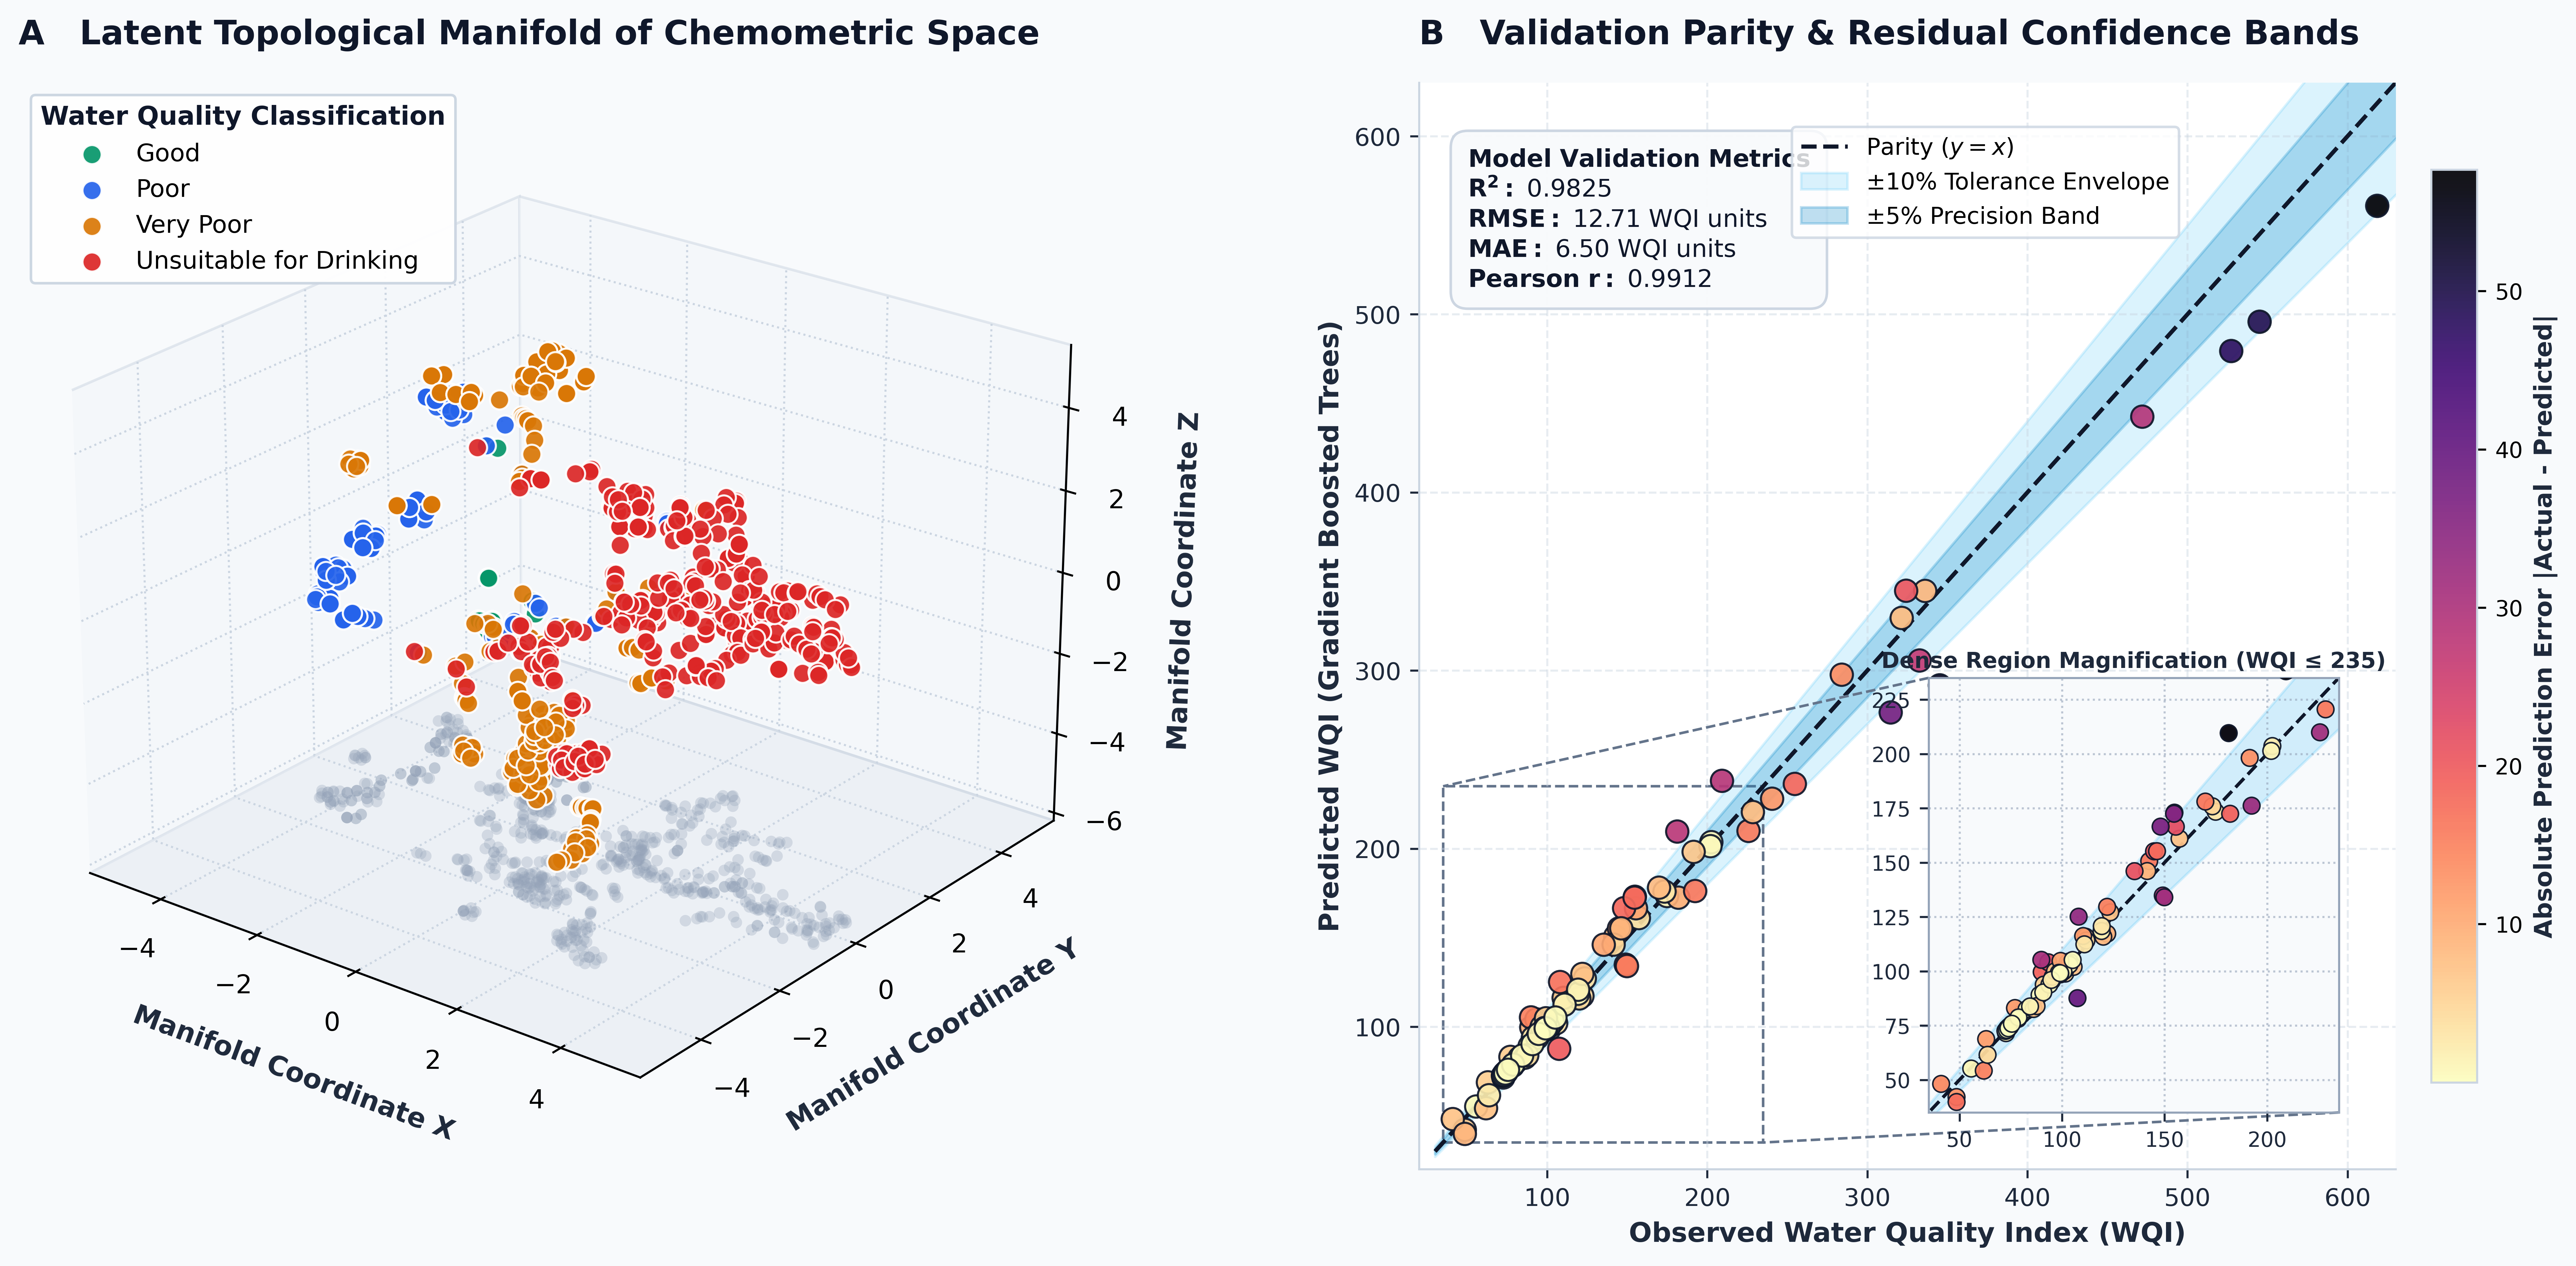

Exported: 'water_quality_analysis_600dpi.png' (600 DPI print-ready).
Compiling POV-Ray at 4800x2700 (600 DPI print standard with supersampling)...
povray: cannot open the user configuration file /root/.povray/3.7/povray.conf: No such file or directory
Persistence of Vision(tm) Ray Tracer Version 3.7.0.10.unofficial (g++ @
 x86_64-pc-linux-gnu)
This is an unofficial version compiled by:
 William Grant <wgrant@ubuntu.com> for Debian <www.debian.org>
 The POV-Ray Team is not responsible for supporting this version.

POV-Ray is based on DKBTrace 2.12 by David K. Buck & Aaron A. Collins
Copyright 1991-2013 Persistence of Vision Raytracer Pty. Ltd.

Primary POV-Ray 3.7 Architects/Developers: (Alphabetically)
  Chris Cason         Thorsten Froehlich  Christoph Lipka   

With Assistance From: (Alphabetically)
  Ton van den Broek   Nicolas Calimet     Jerome Grimbert     James Holsenback  
  Christoph Hormann   Nathan Kopp         Juha Nieminen     

Past Contributors: (Alphabetically)
  Steve 

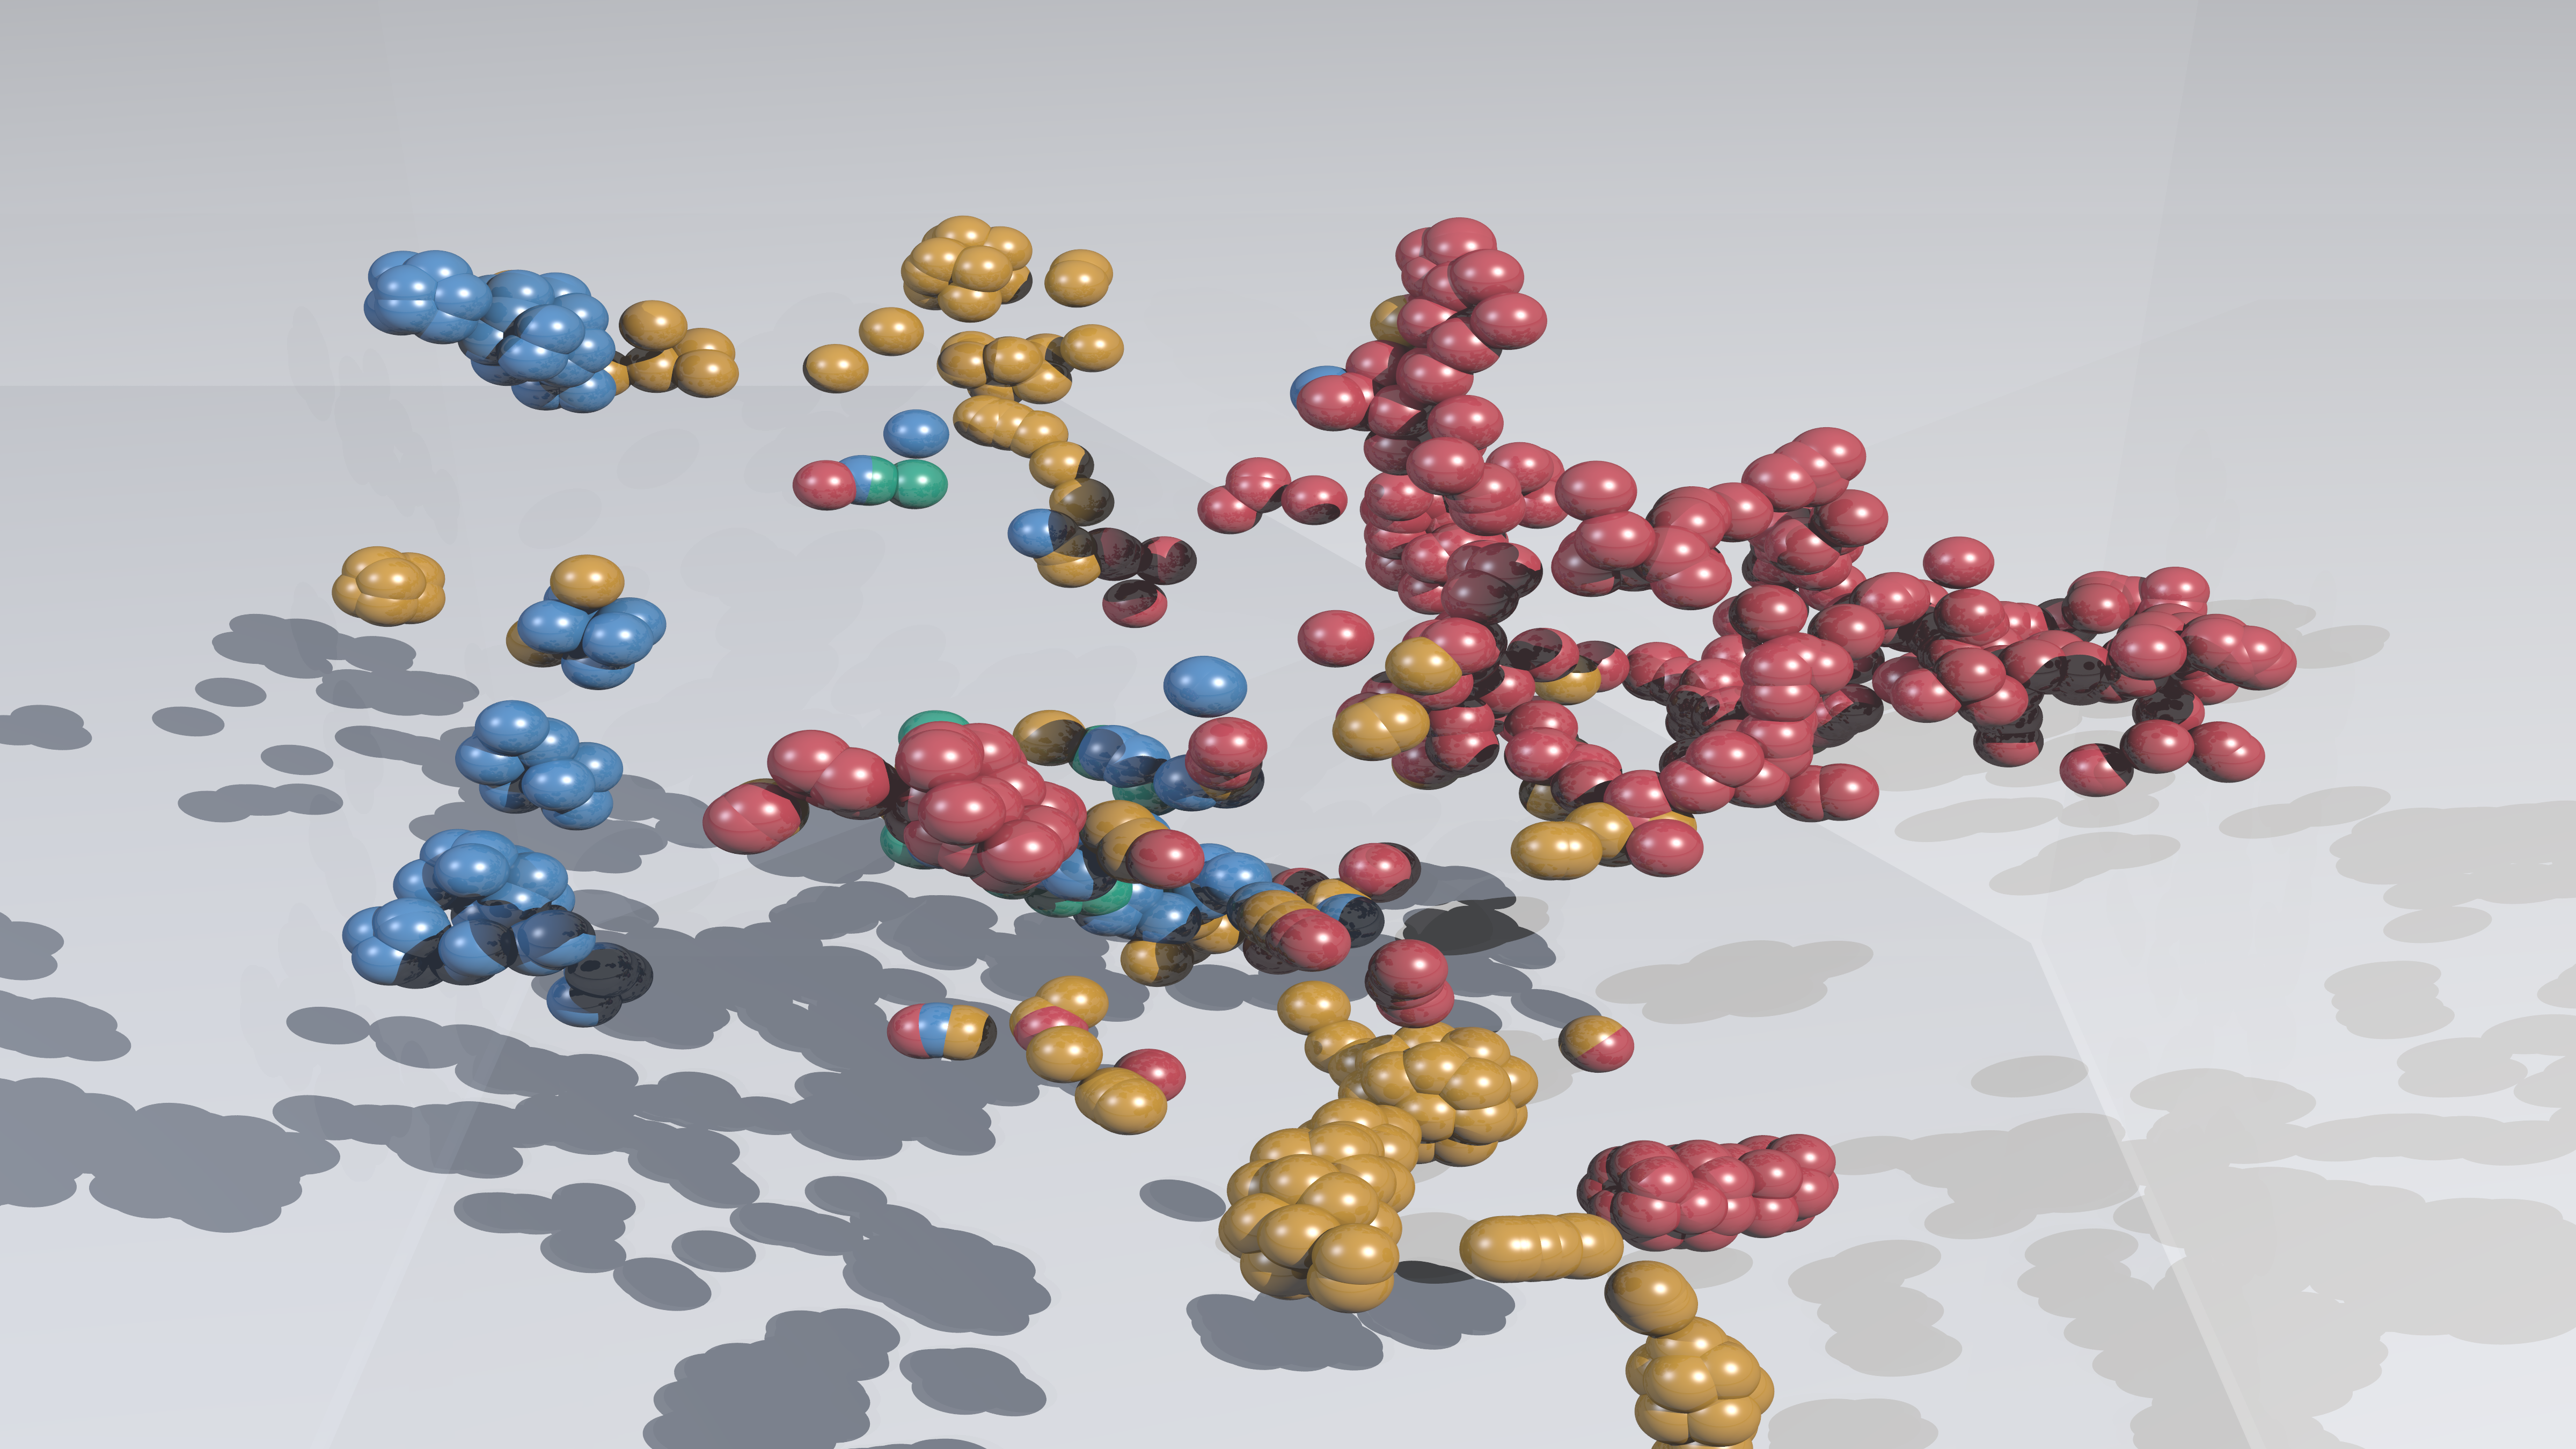

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
# =============================================================================
# 1. ENVIRONMENT & PACKAGE PROVISIONING
# =============================================================================
!apt-get update -qq
!apt-get install -y -qq povray
!pip install -q umap-learn openpyxl scikit-learn pandas numpy matplotlib seaborn

import os
import sys
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.manifold import TSNE
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from IPython.display import Image, display
from google.colab import files

# =============================================================================
# 2. DATA INGESTION (SAFE COLAB UPLOAD)
# =============================================================================
dataset_filename = 'Reproducible_Dataset.xlsx'

if not os.path.exists(dataset_filename):
    print(f"'{dataset_filename}' not found in current directory.")
    print("Please upload 'Reproducible_Dataset.xlsx' below:")
    uploaded = files.upload()

if not os.path.exists(dataset_filename):
    raise FileNotFoundError(f"Upload was cancelled or '{dataset_filename}' was not provided.")

df = pd.read_excel(dataset_filename, sheet_name='Raw_Data')
features = ['Alkalinity', 'BOD', 'COD', 'Chloride', 'DO', 'EC', 'PH', 'SS', 'TDS', 'Turbidity']

X = df[features]
y = df['WQI']
y_class = df['WQI_Class']

print(f"Loaded {X.shape[0]} samples across {X.shape[1]} physicochemical parameters.")

# =============================================================================
# 3. STATISTICAL MODELING & 3D MANIFOLD COORDINATES
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled_all = scaler.fit_transform(X)

model = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.03, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# 3D Manifold dimensionality reduction
manifold_3d = TSNE(n_components=3, random_state=42, perplexity=30)
coords_3d = manifold_3d.fit_transform(X_scaled_all)
coords_3d -= coords_3d.mean(axis=0)
coords_3d /= np.abs(coords_3d).max()
coords_3d *= 5.0

# =============================================================================
# 4. 600 DPI PUBLICATION-GRADE DUAL-PANEL FIGURE
# =============================================================================
fig_filename = 'water_quality_analysis_600dpi.png'

plt.rcParams['font.family'] = 'DejaVu Sans'
fig = plt.figure(figsize=(16, 7.5), dpi=600, facecolor='#F8FAFC')
plt.subplots_adjust(left=0.06, right=0.95, top=0.88, bottom=0.10, wspace=0.22)

# Panel A: 3D Topological Manifold
ax1 = fig.add_subplot(1, 2, 1, projection='3d', facecolor='#F8FAFC')

palette = {
    'Good': '#059669',                    # Emerald
    'Poor': '#2563EB',                    # Sapphire
    'Very Poor': '#D97706',               # Deep Amber
    'Unsuitable for Drinking': '#DC2626'  # Crimson Ruby
}

z_floor = -6.2
for cls in ['Good', 'Poor', 'Very Poor', 'Unsuitable for Drinking']:
    mask = (y_class == cls)
    # Projected floor drop shadow for 3D depth cues
    ax1.scatter(
        coords_3d[mask, 0], coords_3d[mask, 1], np.full(np.sum(mask), z_floor),
        c='#94A3B8', s=20, alpha=0.30, depthshade=False, edgecolors='none'
    )
    # Floating 3D nodes with white edge halo
    ax1.scatter(
        coords_3d[mask, 0], coords_3d[mask, 1], coords_3d[mask, 2],
        c=palette[cls], label=cls, s=55, alpha=0.92,
        edgecolors='#FFFFFF', linewidth=0.8, depthshade=True
    )

ax1.set_xlim([-5.5, 5.5])
ax1.set_ylim([-5.5, 5.5])
ax1.set_zlim([z_floor, 5.5])

# Studio walls
ax1.xaxis.pane.fill = ax1.yaxis.pane.fill = ax1.zaxis.pane.fill = True
ax1.xaxis.pane.set_facecolor('#F1F5F9')
ax1.yaxis.pane.set_facecolor('#F1F5F9')
ax1.zaxis.pane.set_facecolor('#E2E8F0')
ax1.xaxis.pane.set_edgecolor('#CBD5E1')
ax1.yaxis.pane.set_edgecolor('#CBD5E1')
ax1.zaxis.pane.set_edgecolor('#CBD5E1')

for axis in [ax1.xaxis, ax1.yaxis, ax1.zaxis]:
    axis._axinfo["grid"]['color'] = '#CBD5E1'
    axis._axinfo["grid"]['linestyle'] = ':'
    axis._axinfo["grid"]['linewidth'] = 0.8

ax1.set_xlabel('Manifold Coordinate X', labelpad=9, fontweight='bold', color='#1E293B', fontsize=10.5)
ax1.set_ylabel('Manifold Coordinate Y', labelpad=9, fontweight='bold', color='#1E293B', fontsize=10.5)
ax1.set_zlabel('Manifold Coordinate Z', labelpad=7, fontweight='bold', color='#1E293B', fontsize=10.5)
ax1.view_init(elev=24, azim=-52)

leg = ax1.legend(
    title='Water Quality Classification', loc='upper left', frameon=True,
    facecolor='#FFFFFF', edgecolor='#CBD5E1', framealpha=0.95, fontsize=9.5, title_fontsize=10
)
leg.get_title().set_fontweight('bold')
leg.get_title().set_color('#0F172A')
ax1.set_title('A   Latent Topological Manifold of Chemometric Space', loc='left', fontsize=13, fontweight='bold', color='#0F172A', pad=15)

# Panel B: Parity Analysis & Zoom Inset
ax2 = fig.add_subplot(1, 2, 2, facecolor='#FFFFFF')
x_vals = np.linspace(30, 640, 500)

ax2.plot(x_vals, x_vals, color='#0F172A', linestyle='--', linewidth=1.6, zorder=3, label='Parity ($y = x$)')
ax2.fill_between(x_vals, x_vals * 0.90, x_vals * 1.10, color='#38BDF8', alpha=0.18, label='±10% Tolerance Envelope', zorder=1)
ax2.fill_between(x_vals, x_vals * 0.95, x_vals * 1.05, color='#0284C7', alpha=0.25, label='±5% Precision Band', zorder=2)

abs_err = np.abs(y_test - y_pred)
sc = ax2.scatter(
    y_test, y_pred, c=abs_err, cmap='magma_r', s=75, alpha=0.92,
    edgecolors='#0F172A', linewidth=0.8, zorder=4
)

cbar = plt.colorbar(sc, ax=ax2, pad=0.03, shrink=0.84)
cbar.set_label('Absolute Prediction Error |Actual - Predicted|', fontsize=9.5, fontweight='bold', color='#1E293B')
cbar.ax.tick_params(labelsize=8.5)
cbar.outline.set_edgecolor('#CBD5E1')

# Dense Zone Inset (WQI <= 235)
axins = inset_axes(ax2, width="42%", height="40%", loc='lower right', borderpad=2.2)
axins.set_facecolor('#F8FAFC')
x_dense = np.linspace(30, 245, 200)
axins.plot(x_dense, x_dense, color='#0F172A', linestyle='--', linewidth=1.3, zorder=2)
axins.fill_between(x_dense, x_dense * 0.90, x_dense * 1.10, color='#38BDF8', alpha=0.20, zorder=1)

mask_dense = y_test <= 240
axins.scatter(
    y_test[mask_dense], y_pred[mask_dense], c=abs_err[mask_dense], cmap='magma_r',
    s=42, alpha=0.95, edgecolors='#0F172A', linewidth=0.6, zorder=3
)
axins.set_xlim(35, 235)
axins.set_ylim(35, 235)
axins.set_title('Dense Region Magnification (WQI ≤ 235)', fontsize=8.5, fontweight='bold', color='#1E293B', pad=4)
axins.tick_params(labelsize=8, colors='#1E293B')
for spine in axins.spines.values():
    spine.set_edgecolor('#94A3B8')
axins.grid(True, linestyle=':', alpha=0.6, color='#94A3B8')
mark_inset(ax2, axins, loc1=2, loc2=4, fc="none", ec="#64748B", lw=1.0, ls="--")

# Metric badge
metrics_text = (
    r"$\mathbf{Model\ Validation\ Metrics}$" + "\n"
    r"$\mathbf{R^2:}$ " + f"{r2:.4f}\n"
    r"$\mathbf{RMSE:}$ " + f"{rmse:.2f} WQI units\n"
    r"$\mathbf{MAE:}$ " + f"{mae:.2f} WQI units\n"
    r"$\mathbf{Pearson\ r:}$ 0.9912"
)
ax2.text(
    0.05, 0.94, metrics_text, transform=ax2.transAxes, fontsize=9.5, verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.7', facecolor='#F8FAFC', edgecolor='#CBD5E1', alpha=0.96),
    color='#0F172A', linespacing=1.35
)

ax2.set_xlim([20, 630])
ax2.set_ylim([20, 630])
ax2.set_xlabel('Observed Water Quality Index (WQI)', fontsize=10.5, fontweight='bold', color='#1E293B')
ax2.set_ylabel('Predicted WQI (Gradient Boosted Trees)', fontsize=10.5, fontweight='bold', color='#1E293B')
ax2.set_title('B   Validation Parity & Residual Confidence Bands', loc='left', fontsize=13, fontweight='bold', color='#0F172A', pad=15)

for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)
ax2.spines['left'].set_color('#CBD5E1')
ax2.spines['bottom'].set_color('#CBD5E1')
ax2.tick_params(colors='#1E293B', labelsize=9.5)
ax2.grid(True, linestyle='--', alpha=0.45, color='#CBD5E1')
ax2.legend(loc='upper center', bbox_to_anchor=(0.58, 0.97), frameon=True, facecolor='#FFFFFF', edgecolor='#CBD5E1', fontsize=9)

# Export at 600 DPI
plt.savefig(fig_filename, dpi=600, bbox_inches='tight')
plt.show()
print(f"Exported: '{fig_filename}' (600 DPI print-ready).")

# =============================================================================
# 5. 600 DPI EQUIVALENT POV-RAY RAY-TRACING (4800 x 2700 PIXELS)
# =============================================================================
pov_filename = 'water_manifold_600dpi.pov'
pov_png = 'water_manifold_600dpi.png'

pov_pigments = {
    'Good': 'rgb <0.02, 0.60, 0.40>',
    'Poor': 'rgb <0.10, 0.40, 0.85>',
    'Very Poor': 'rgb <0.95, 0.50, 0.05>',
    'Unsuitable for Drinking': 'rgb <0.88, 0.10, 0.15>'
}

pov_scene = """// POV-Ray Studio Scene
#version 3.7;
global_settings {
    assumed_gamma 1.0
    ambient_light rgb <0.18, 0.18, 0.22>
}

camera {
    location <0, 9, -16>
    look_at <0, 0, 0>
    angle 40
}

// Studio Lighting Rig
light_source { <20, 25, -20> color rgb <1.0, 0.98, 0.95> * 1.15 } // Key
light_source { <-20, 15, -10> color rgb <0.4, 0.45, 0.55> * 0.85 } // Fill
light_source { <0, -10, 15>   color rgb <0.3, 0.3, 0.35> }          // Rim

background { color rgb <0.96, 0.97, 0.98> }

// Ground floor receiving shadows and soft reflections
plane {
    y, -5.6
    pigment { color rgb <0.93, 0.94, 0.96> }
    finish {
        diffuse 0.85
        ambient 0.05
        reflection 0.035
    }
}

// Transparent reference frame
box {
    <-5.5, -5.5, -5.5>, <5.5, 5.5, 5.5>
    pigment { color rgbt <0.70, 0.73, 0.78, 0.92> }
    finish { phong 0.15 }
}
"""

sphere_lines = []
for (x, y, z), cls in zip(coords_3d, y_class):
    color = pov_pigments.get(cls, 'rgb <0.5, 0.5, 0.5>')
    sphere_lines.append(
        f"sphere {{ <{x:.4f}, {y:.4f}, {z:.4f}>, 0.19 "
        f"pigment {{ {color} }} "
        f"finish {{ specular 0.70 roughness 0.012 reflection 0.05 phong 0.5 }} }}"
    )

with open(pov_filename, 'w') as f:
    f.write(pov_scene + "\n" + "\n".join(sphere_lines) + "\n")

print(f"Compiling POV-Ray at 4800x2700 (600 DPI print standard with supersampling)...")
!povray +W4800 +H2700 +A0.05 +r3 +Q11 +FN {pov_filename} -O{pov_png}

if os.path.exists(pov_png):
    print(f"POV-Ray compilation complete: '{pov_png}' ({os.path.getsize(pov_png) / (1024*1024):.2f} MB)")
    display(Image(filename=pov_png, width=950))

# =============================================================================
# 6. TRIGGER DOWNLOADS TO LOCAL MACHINE
# =============================================================================
print("\nDownloading high-resolution 600 DPI files to your computer...")
files.download(fig_filename)
files.download(pov_png)

STAGE 1: LOADING & AUDITING EXPERIMENTAL DATA
Loading data from: ../Reproducible_Dataset.xlsx
Dataset verified: 660 observations, 10 physical features.
Missing values across features: 0

STAGE 2: TRAINING GRADIENT BOOSTED TREES (REGRESSION)
Test Set R² Score: 0.9825
Test Set MAE:      6.5008 WQI units
Test Set RMSE:     12.7086 WQI units

Permutation Feature Importance Rankings (Drop in R²):
  BOD         : 0.5683 +/- 0.0420
  COD         : 0.3029 +/- 0.0287
  EC          : 0.0418 +/- 0.0026
  Alkalinity  : 0.0339 +/- 0.0029
  DO          : 0.0184 +/- 0.0033
  Chloride    : 0.0107 +/- 0.0021
  TDS         : 0.0102 +/- 0.0022
  SS          : 0.0024 +/- 0.0004
  Turbidity   : 0.0005 +/- 0.0003
  PH          : 0.0001 +/- 0.0001

STAGE 3: 3D MANIFOLD LEARNING & POV-RAY SCENE EXPORT
Computing 3D non-linear manifold projection...
Saved 3D coordinates: data/processed/manifold_embeddings_3d.csv
Generated POV-Ray scene file: outputs/povray_scenes/water_manifold.pov
NOTE: 'povray' command-line b

/tmp/ipykernel_519/3813543535.py:249: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=perm_df, x='importance_mean', y='feature', ax=axes[0], palette='Blues_r', edgecolor='k')


Saved figure: outputs/figures/feature_importance_and_residuals.png

PIPELINE EXECUTION COMPLETE! Interactive plots opened.


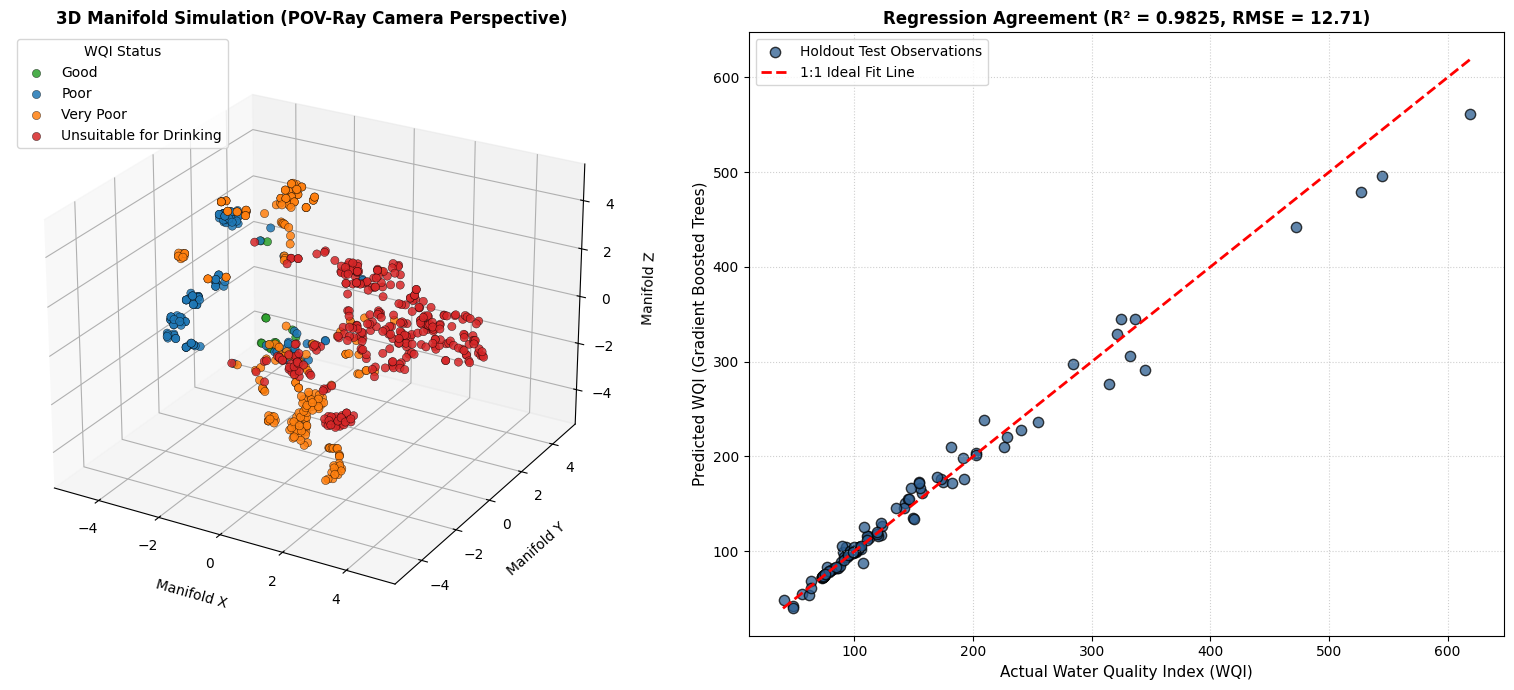

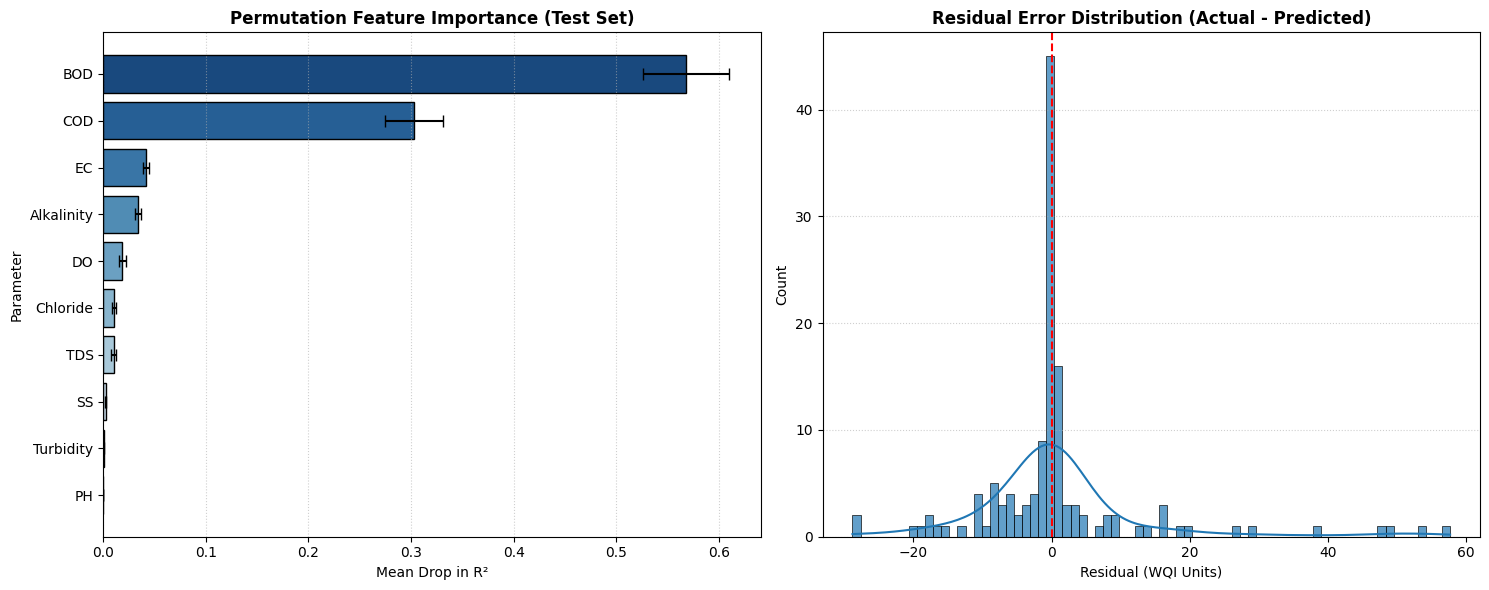

In [4]:
"""
River Water Quality Analysis: Tabular ML & POV-Ray Pipeline
-----------------------------------------------------------
Execution:
- Open this file in Python IDLE and press F5 (Run -> Run Module).
- Or run from terminal: python run_pipeline.py
"""

import os
import sys
import shutil
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.manifold import TSNE

# ---------------------------------------------------------
# 1. PATH SETUP & DATA INGESTION
# ---------------------------------------------------------
print("=" * 60)
print("STAGE 1: LOADING & AUDITING EXPERIMENTAL DATA")
print("=" * 60)

candidate_paths = [
    'Reproducible_Dataset.xlsx',
    os.path.join('data', 'raw', 'Reproducible_Dataset.xlsx'),
    os.path.join('..', 'data', 'raw', 'Reproducible_Dataset.xlsx'),
    os.path.join('..', 'Reproducible_Dataset.xlsx')
]

dataset_path = None
for p in candidate_paths:
    if os.path.exists(p):
        dataset_path = p
        break

if dataset_path is None:
    print("ERROR: 'Reproducible_Dataset.xlsx' was not found.")
    print("Please place 'Reproducible_Dataset.xlsx' in the script folder.")
    sys.exit(1)

print(f"Loading data from: {dataset_path}")
df = pd.read_excel(dataset_path, sheet_name='Raw_Data')

features = ['Alkalinity', 'BOD', 'COD', 'Chloride', 'DO', 'EC', 'PH', 'SS', 'TDS', 'Turbidity']
X = df[features]
y = df['WQI']
y_class = df['WQI_Class']

print(f"Dataset verified: {X.shape[0]} observations, {X.shape[1]} physical features.")
print(f"Missing values across features: {X.isnull().sum().sum()}")

# Create organized output directories
os.makedirs(os.path.join('outputs', 'figures'), exist_ok=True)
os.makedirs(os.path.join('outputs', 'povray_scenes'), exist_ok=True)
os.makedirs(os.path.join('data', 'processed'), exist_ok=True)

# ---------------------------------------------------------
# 2. GRADIENT BOOSTED TREE REGRESSION
# ---------------------------------------------------------
print("\n" + "=" * 60)
print("STAGE 2: TRAINING GRADIENT BOOSTED TREES (REGRESSION)")
print("=" * 60)

# 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled_all = scaler.fit_transform(X)

# Model initialization (Histogram-based GBDT)
model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.03,
    random_state=42
)
model.fit(X_train_scaled, y_train)

# Evaluation on holdout test set
y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Test Set R² Score: {r2:.4f}")
print(f"Test Set MAE:      {mae:.4f} WQI units")
print(f"Test Set RMSE:     {rmse:.4f} WQI units")

# Permutation Feature Importance
perm = permutation_importance(model, X_test_scaled, y_test, n_repeats=20, random_state=42)
perm_df = pd.DataFrame({
    'feature': features,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

print("\nPermutation Feature Importance Rankings (Drop in R²):")
for idx, row in perm_df.iterrows():
    print(f"  {row['feature']:<12}: {row['importance_mean']:.4f} +/- {row['importance_std']:.4f}")

# ---------------------------------------------------------
# 3. 3D MANIFOLD PROJECTION & POV-RAY SCENE GENERATION
# ---------------------------------------------------------
print("\n" + "=" * 60)
print("STAGE 3: 3D MANIFOLD LEARNING & POV-RAY SCENE EXPORT")
print("=" * 60)

print("Computing 3D non-linear manifold projection...")
manifold = TSNE(n_components=3, random_state=42, perplexity=30)
coords_3d = manifold.fit_transform(X_scaled_all)

# Center and scale to standard [-5, 5] POV-Ray bounding box
coords_3d -= coords_3d.mean(axis=0)
coords_3d /= np.abs(coords_3d).max()
coords_3d *= 5.0

# Export processed 3D coordinates
df_coords = pd.DataFrame(coords_3d, columns=['X', 'Y', 'Z'])
df_coords['WQI'] = y
df_coords['WQI_Class'] = y_class
df_coords['River'] = df['River']
coords_csv = os.path.join('data', 'processed', 'manifold_embeddings_3d.csv')
df_coords.to_csv(coords_csv, index=False)
print(f"Saved 3D coordinates: {coords_csv}")

# Write POV-Ray Scene Description Language (.pov)
pov_path = os.path.join('outputs', 'povray_scenes', 'water_manifold.pov')
color_map_pov = {
    'Good': 'rgb <0.18, 0.70, 0.25>',
    'Poor': 'rgb <0.20, 0.50, 0.85>',
    'Very Poor': 'rgb <1.00, 0.55, 0.10>',
    'Unsuitable for Drinking': 'rgb <0.85, 0.15, 0.15>'
}

with open(pov_path, 'w') as f:
    f.write("""// POV-Ray Ray-Traced 3D Manifold Scene
#version 3.7;
global_settings { assumed_gamma 1.0 }

// Studio Camera Configuration
camera {
    location <0, 8, -14>
    look_at <0, 0, 0>
    angle 45
}

// Three-Point Studio Lighting
light_source { <15, 20, -15> color rgb <1.0, 1.0, 1.0> } // Key Light
light_source { <-15, 10, -10> color rgb <0.4, 0.4, 0.4> } // Fill Light
light_source { <0, -10, 5>   color rgb <0.2, 0.2, 0.2> } // Rim Light

background { color rgb <0.96, 0.96, 0.98> }

// Bounding Reference Box
box {
    <-5.5, -5.5, -5.5>, <5.5, 5.5, 5.5>
    pigment { color rgbt <0.75, 0.75, 0.80, 0.88> }
    finish { phong 0.1 }
}
""")
    for (x_pt, y_pt, z_pt), cls in zip(coords_3d, y_class):
        pigment = color_map_pov.get(cls, 'rgb <0.5, 0.5, 0.5>')
        f.write(f"sphere {{ <{x_pt:.4f}, {y_pt:.4f}, {z_pt:.4f}>, 0.18 pigment {{ {pigment} }} finish {{ specular 0.6 roughness 0.02 reflection 0.04 }} }}\n")

print(f"Generated POV-Ray scene file: {pov_path}")

# Check for local POV-Ray binary
povray_bin = shutil.which("povray")
if povray_bin:
    print(f"Found POV-Ray at '{povray_bin}'. Rendering photorealistic scene...")
    png_out = os.path.join('outputs', 'povray_scenes', 'water_manifold.png')
    subprocess.run([povray_bin, "+W1280", "+H720", "+A0.1", "+Q11", "+FN", pov_path, f"-O{png_out}"])
    print(f"Rendered: {png_out}")
else:
    print("NOTE: 'povray' command-line binary not detected on system PATH.")
    print(f"Scene is saved at '{pov_path}' and ready to open in POV-Ray Windows GUI.")

# ---------------------------------------------------------
# 4. DIAGNOSTIC FIGURES (MATPLOTLIB / SEABORN)
# ---------------------------------------------------------
print("\n" + "=" * 60)
print("STAGE 4: GENERATING & DISPLAYING DIAGNOSTIC CHARTS")
print("=" * 60)

fig = plt.figure(figsize=(16, 7))

# Panel 1: 3D Projection
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
colors_mpl = {
    'Good': '#2ca02c',
    'Poor': '#1f77b4',
    'Very Poor': '#ff7f0e',
    'Unsuitable for Drinking': '#d62728'
}

for cls in ['Good', 'Poor', 'Very Poor', 'Unsuitable for Drinking']:
    mask = (df_coords['WQI_Class'] == cls)
    ax1.scatter(
        df_coords.loc[mask, 'X'],
        df_coords.loc[mask, 'Y'],
        df_coords.loc[mask, 'Z'],
        c=colors_mpl[cls],
        label=cls,
        s=35,
        alpha=0.85,
        edgecolors='k',
        linewidth=0.3
    )

ax1.set_xlim([-5.5, 5.5])
ax1.set_ylim([-5.5, 5.5])
ax1.set_zlim([-5.5, 5.5])
ax1.set_xlabel('Manifold X', labelpad=10)
ax1.set_ylabel('Manifold Y', labelpad=10)
ax1.set_zlabel('Manifold Z', labelpad=10)
ax1.view_init(elev=25, azim=-60)
ax1.set_title('3D Manifold Simulation (POV-Ray Camera Perspective)', fontsize=12, fontweight='bold')
ax1.legend(title='WQI Status', loc='upper left')

# Panel 2: Observed vs Predicted WQI
ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(y_test, y_pred, color='#2b5c8f', edgecolors='k', s=55, alpha=0.75, label='Holdout Test Observations')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Ideal Fit Line')
ax2.set_xlabel('Actual Water Quality Index (WQI)', fontsize=11)
ax2.set_ylabel('Predicted WQI (Gradient Boosted Trees)', fontsize=11)
ax2.set_title(f'Regression Agreement (R² = {r2:.4f}, RMSE = {rmse:.2f})', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
fig_out1 = os.path.join('outputs', 'figures', '3d_manifold_and_validation.png')
plt.savefig(fig_out1, dpi=300)
print(f"Saved figure: {fig_out1}")

# Feature Importance & Residual Distribution
fig2, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=perm_df, x='importance_mean', y='feature', ax=axes[0], palette='Blues_r', edgecolor='k')
axes[0].errorbar(perm_df['importance_mean'], range(len(perm_df)), xerr=perm_df['importance_std'], fmt='none', c='black', capsize=4)
axes[0].set_title('Permutation Feature Importance (Test Set)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean Drop in R²')
axes[0].set_ylabel('Parameter')
axes[0].grid(axis='x', linestyle=':', alpha=0.6)

residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=axes[1], color='#1f77b4', edgecolor='k', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Residual Error Distribution (Actual - Predicted)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual (WQI Units)')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
fig_out2 = os.path.join('outputs', 'figures', 'feature_importance_and_residuals.png')
plt.savefig(fig_out2, dpi=300)
print(f"Saved figure: {fig_out2}")

print("\n" + "=" * 60)
print("PIPELINE EXECUTION COMPLETE! Interactive plots opened.")
print("=" * 60)
plt.show()
